# Observables
Let $\tilde{S}_{iy}$ be the "raw" size of firm $i$ at year $y$, we then normalize it by dividing it with the average market size at that time
$$
S_{iy} = N_y \frac{\tilde{S}_{iy}}{\sum_i \tilde{S}_{iy}}
$$
where $N_y$ is the number of observation in a "year", it's always equal to $N$ is our case

then we define the growth rate as
$$
g_{iy} = \ln\left(\frac{S_{iy+1}}{S_{iy}}\right) = \ln(S_{iy+1}) - \ln(S_{iy}) =  \ln(\tilde{S}_{iy+1}) - \ln(\tilde{S}_{iy}) + \left[\ln\left(\sum_i \tilde{S}_{iy}\right) -  \ln\left(\sum_i \tilde{S}_{iy+1}\right) \right]
$$
from this the growth volatility is calculated using the adjusted mean absolute deviation
$$
\sigma_i = \sqrt{\frac{\pi}{2}} \frac{1}{T_i} \sum_y |g_{iy} - \bar{g}_i|
$$


In the paper "Firm-level production networks: what do we (really) know?" by Bacilieri et al. they describe the average degree in the network scaling as
$$
\bar{k} \sim N^{\eta}
$$
where $\eta \approx 0.13$

![](images/volatility_vs_size_bm.png)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import glv

In [2]:
N = 1000
C = 50
sigma = 0.2

# Configuration model with exponential degree distribution: g = k/C ~ Exp(1)
nu_pdf = lambda g: np.exp(-g)

mu_c_result = glv.calculate_mu_c(sigma=sigma, gamma=0.0, nu_pdf=nu_pdf)
mu_c = mu_c_result["mu_c"]
print(f"mu_c = {mu_c:.4f}")
print(f"q*   = {mu_c_result['q_star']:.4f}")
print(f"chi* = {mu_c_result['chi_star']:.4f}")

mu_c = 0.4990
q*   = 6.5557
chi* = 0.9746


In [3]:
degree_sequence = np.maximum(np.random.exponential(scale=C, size=N).astype(int), 1)
if np.sum(degree_sequence) % 2 != 0:
    degree_sequence[0] += 1

# Build topology (find_empirical_mu_c only uses the non-zero structure)
A = glv.generate_matrix(degree_sequence, C, mu=mu_c, sigma=sigma)

# Initial conditions for the mu sweep
n_ic = 10
initial_conditions = []
for _ in range(n_ic):
    x0 = np.random.uniform(0.1, 1.0, N)
    M0 = x0.sum()
    initial_conditions.append(np.concatenate([x0 / M0, [M0], [0.0]]))

fit = glv.find_empirical_mu_c(
    mu_c_theoretical=mu_c,
    A=A,
    C=C,
    sigma=sigma,
    initial_conditions=initial_conditions,
)
mu_c_empirical = fit["mu_c"]
print(f"Theoretical mu_c = {mu_c:.4f}")
print(f"Empirical   mu_c = {mu_c_empirical:.4f}")

KeyboardInterrupt: 

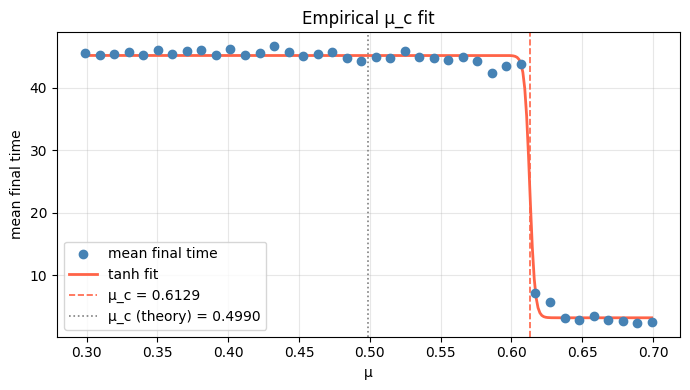

In [ ]:
mu_values = fit["mu_values"]
mean_t    = fit["mean_t"]
amp, a, mu0, b = fit["popt"]

mu_dense = np.linspace(mu_values[0], mu_values[-1], 300)
tanh_fit = amp * np.tanh(-a * (mu_dense - mu0)) + b

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(mu_values, mean_t, color='steelblue', zorder=3, label='mean final time')
ax.plot(mu_dense, tanh_fit, color='tomato', lw=2, label='tanh fit')
ax.axvline(mu_c_empirical, color='tomato', lw=1.2, ls='--', label=f'μ_c = {mu_c_empirical:.4f}')
ax.axvline(mu_c, color='gray', lw=1.2, ls=':', label=f'μ_c (theory) = {mu_c:.4f}')
ax.set(xlabel='μ', ylabel='mean final time', title='Empirical μ_c fit')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
W_sparse = glv.generate_matrix(degree_sequence, C, mu=mu_c_empirical, sigma=sigma)

x_initial = np.random.uniform(0.1, 1.0, N)
M_0 = x_initial.sum()
y_0 = x_initial / M_0
initial_state = np.concatenate([y_0, [M_0], [0.0]])

tau_span = (0, 1e6)
tau_eval = np.linspace(*tau_span, 1000)

solution = solve_ivp(
    fun=glv.rescaled_glv_sparse,
    t_span=tau_span,
    y0=initial_state,
    t_eval=tau_eval,
    args=(N, W_sparse),
    method='RK45',
    max_step=1e2,
)

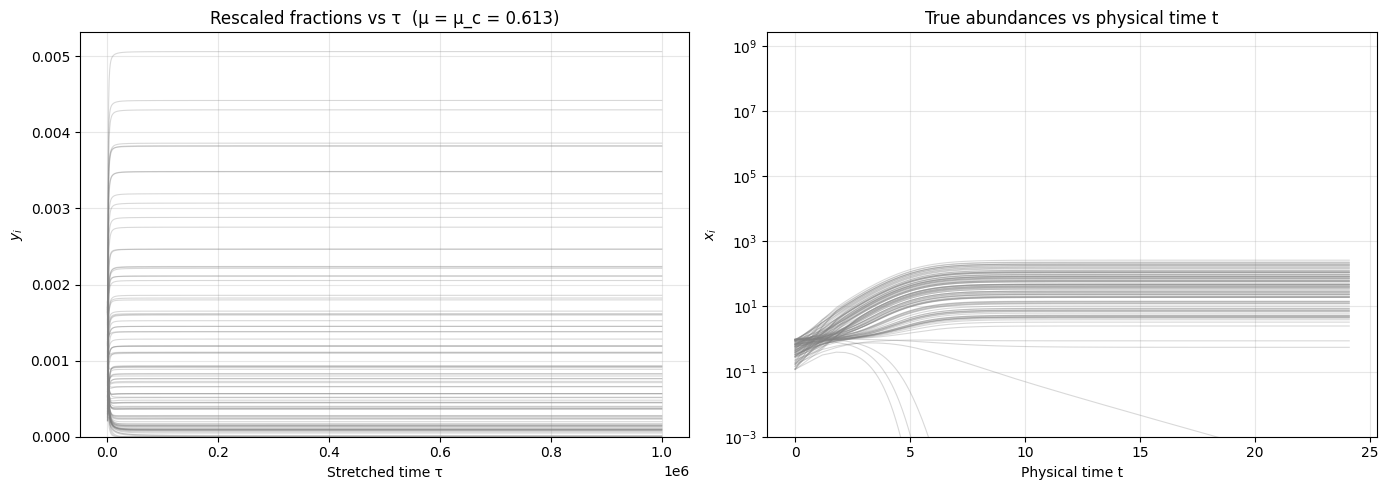

Finite-time singularity: t* ≈ 24.1007


In [ ]:
y_traj = solution.y[:N, :]
M_traj = solution.y[N, :]
t_traj = solution.y[N + 1, :]
x_traj = y_traj * M_traj  # convert rescaled -> true variables: x_i = y_i * M

sample = np.random.choice(N, size=100, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in sample:
    axes[0].plot(solution.t, y_traj[i], lw=0.8, color='gray', alpha=0.3)
    axes[1].plot(t_traj, x_traj[i], lw=0.8, color='gray', alpha=0.3)

axes[0].set(
    title=f"Rescaled fractions vs τ  (μ = μ_c = {mu_c_empirical:.3f})",
    xlabel="Stretched time τ", ylabel="$y_i$", ylim=(0, None),
)
axes[0].grid(alpha=0.3)

axes[1].set(
    title="True abundances vs physical time t",
    xlabel="Physical time t", ylabel="$x_i$", yscale='log',
)
axes[1].set_ylim(1e-3, None)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Finite-time singularity: t* ≈ {t_traj[-1]:.4f}")

Physical time span: t ∈ [0, 24.1007]
dt_year = 0.2410,  n_years = 100


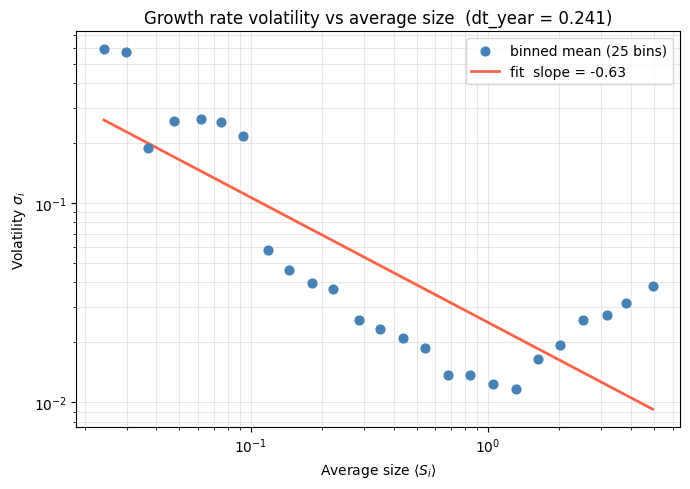

Power-law slope: -0.627


In [ ]:
print(f"Physical time span: t ∈ [0, {t_traj[-1]:.4f}]")

# --- define yearly resolution ---
dt_year = t_traj[-1] / 100          # 100 "years" across the simulation; adjust as needed
t_years = np.arange(t_traj[0], t_traj[-1], dt_year)
print(f"dt_year = {dt_year:.4f},  n_years = {len(t_years)}")

# Interpolate each species onto the regular physical-time grid
x_yearly = np.array([np.interp(t_years, t_traj, x_traj[i]) for i in range(N)])  # (N, n_years)

# Normalised sizes: S_i(y) = N * x_i(y) / sum_j x_j(y)
S = N * x_yearly / x_yearly.sum(axis=0, keepdims=True)   # (N, n_years)

# Log growth rates between consecutive years
log_S = np.log(np.maximum(S, 1e-15))
g = np.diff(log_S, axis=1)                               # (N, n_years - 1)

# Per-species volatility: sigma_i = sqrt(pi/2) * MAD
g_bar = g.mean(axis=1, keepdims=True)
volatility = np.sqrt(np.pi / 2) * np.mean(np.abs(g - g_bar), axis=1)

# Per-species time-average size
avg_size = S.mean(axis=1)

# --- bin into 25 log-spaced bins by average size ---
mask = (avg_size > 0) & (volatility > 0)
s_valid = avg_size[mask]
v_valid = volatility[mask]

n_bins = 25
bin_edges = np.logspace(np.log10(s_valid.min()), np.log10(s_valid.max()), n_bins + 1)
bin_idx   = np.digitize(s_valid, bin_edges) - 1
bin_idx   = np.clip(bin_idx, 0, n_bins - 1)

bin_s = np.array([s_valid[bin_idx == b].mean() for b in range(n_bins)])
bin_v = np.array([v_valid[bin_idx == b].mean() for b in range(n_bins)])
bin_n = np.array([(bin_idx == b).sum()          for b in range(n_bins)])

# keep only non-empty bins
ok = bin_n > 0
bin_s, bin_v = bin_s[ok], bin_v[ok]

# Log-log linear fit on binned data
log_x = np.log10(bin_s)
log_y = np.log10(bin_v)
slope, intercept = np.polyfit(log_x, log_y, 1)

fit_x = np.linspace(log_x.min(), log_x.max(), 200)
fit_y = slope * fit_x + intercept

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(bin_s, bin_v, s=40, color='steelblue', zorder=3, label='binned mean (25 bins)')
ax.plot(10**fit_x, 10**fit_y, color='tomato', lw=2, label=f'fit  slope = {slope:.2f}')
ax.set(
    xscale='log', yscale='log',
    xlabel=r'Average size $\langle S_i \rangle$',
    ylabel=r'Volatility $\sigma_i$',
    title=f'Growth rate volatility vs average size  (dt_year = {dt_year:.3f})',
)
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()
print(f"Power-law slope: {slope:.3f}")

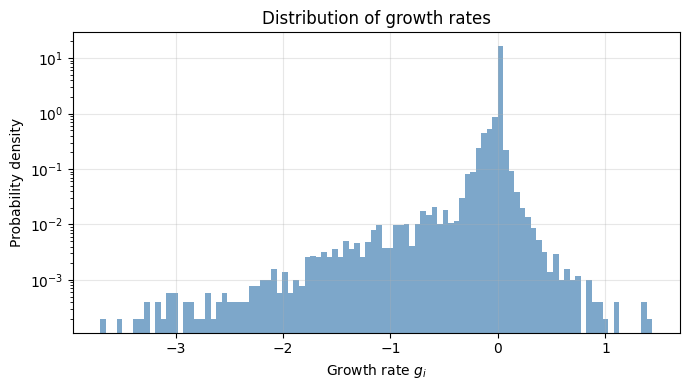

In [ ]:
g_flat = g.ravel()
g_flat = g_flat[np.isfinite(g_flat)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(g_flat, bins=100, density=True, color='steelblue', alpha=0.7)
ax.set(
    xlabel='Growth rate $g_i$',
    ylabel='Probability density',
    title='Distribution of growth rates',
    yscale='log',
)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()